In [ ]:
#needs jetq-coffea environment

from coffea.nanoevents import NanoEventsFactory, PFNanoAODSchema
import fastjet
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import re

import warnings
warnings.filterwarnings("ignore")

import sys

sys.path.append("/uscms_data/d3/azhou/smeft/hbb-run3/src")
sys.path.append('~/nobackup/smeft/topcoffea')
from hbb.utils import load_samples, get_sum_genweights
#from hbb.processors.categorizer import add_weights, get_dataset_norm
import pickle
import uproot
import json

import os
import argparse
from coffea.nanoevents import NanoEventsFactory
from topcoffea.scripts.make_html import make_html
from topcoffea.modules import utils
import topcoffea.modules.quad_fit_tools as qft

In [278]:
start0_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start0_5000.root"
start1_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start1_5000.root"

cHW_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHW_HT2/VBFH_SMEFTsim_100.root"
cHWtil_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHWtil_HT2/VBFH_SMEFTsim_101.root"

#check contents of root:
to_open = uproot.open(start0_sample)
print(to_open.keys())

['tag;1', 'Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']


In [144]:
start0_events = NanoEventsFactory.from_root(
    {start0_sample:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

start1_events = NanoEventsFactory.from_root(
    {start1_sample:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

cHW_events = NanoEventsFactory.from_root(
    {cHW_sample:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

cHWtil_events = NanoEventsFactory.from_root(
    {cHWtil_sample:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

In [125]:
start0_events.fields

['GenJetAK8',
 'luminosityBlock',
 'GenIsolatedPhoton',
 'GenJet',
 'GenVisTau',
 'LHEScaleWeight',
 'EFTfitCoefficients',
 'bunchCrossing',
 'MET',
 'WCnames',
 'LHEPart',
 'event',
 'GenDressedLepton',
 'LHE',
 'run',
 'genWeight',
 'GenMET',
 'GenPart',
 'LHEReweightingWeight',
 'HTXS',
 'PSWeight',
 'GenVtx',
 'LHEPdfWeight',
 'Generator',
 'LHEWeight']

In [191]:
with open('/uscms/home/azhou/nobackup/smeft/cmseft/histograms/vbf_rw_start1_5000_quad_fit_coeff.json', 'r') as file:
    data = json.load(file)
sort = sorted(data.items(), key=lambda kv: (kv[1], kv[0]))
#print(sort)
print(data['cHWtil*cHWtil'])
print(data['cHW*cHW'])

0.033551979809999466
0.04013969004154205


In [265]:
#finding og_wc_point for start1
def get_operator_list_from_json(json_path):
    with open(json_path) as f:
        coeffs_dict = json.load(f)

    first_bin_coeffs = next(iter(coeffs_dict.values()))
    
    ops = set()
    for key in first_bin_coeffs.keys():
        if '*' not in key:
            continue
        left, right = key.split('*')
        for token in (left, right):
            if token != 'sm':
                ops.add(token)
    return sorted(ops)

ops_start1 = get_operator_list_from_json(
    '/uscms/home/azhou/nobackup/smeft/analysis/start1_5000_quad_fit_coeffs_per_bin.json'
)
print(len(ops_start1))
print(set(ops_start1))

og_wc_point_start1 = {op: 1.0 for op in ops_start1}
print(og_wc_point_start1)


22
{'cHudIm', 'cHj1', 'cHWB', 'cHBtil', 'cuBIm', 'cdBIm', 'cHj3', 'cHd', 'cuWRe', 'cdWRe', 'cHudRe', 'cHbox', 'cHWBtil', 'cHB', 'cdWIm', 'cdBRe', 'cHWtil', 'cuBRe', 'cHW', 'cHu', 'cuWIm', 'cHDD'}
{'cHB': 1.0, 'cHBtil': 1.0, 'cHDD': 1.0, 'cHW': 1.0, 'cHWB': 1.0, 'cHWBtil': 1.0, 'cHWtil': 1.0, 'cHbox': 1.0, 'cHd': 1.0, 'cHj1': 1.0, 'cHj3': 1.0, 'cHu': 1.0, 'cHudIm': 1.0, 'cHudRe': 1.0, 'cdBIm': 1.0, 'cdBRe': 1.0, 'cdWIm': 1.0, 'cdWRe': 1.0, 'cuBIm': 1.0, 'cuBRe': 1.0, 'cuWIm': 1.0, 'cuWRe': 1.0}


In [275]:
import re, json
import numpy as np

def F_from_coeffs(coeffs, wc):
    def c(name):
        if name == "sm":
            return 1.0
        return wc.get(name, 0.0)
    total = 0.0
    for key, C in coeffs.items():
        op1, op2 = key.split("*")
        total += C * c(op1) * c(op2)
    return total

with open("start0_5000_quad_fit_coeffs_per_bin.json") as f:
    coeffs_dict = json.load(f)

only_cHW = {"cHW": 1.0}
og_wc_point = {}  # SM

F_ratio_fit = []

for bin_name, coeff_dict in coeffs_dict.items():
    m = re.search(r"(\d+)$", bin_name)
    if not m:
        continue
    b = int(m.group(1))
    F_sm  = F_from_coeffs(coeff_dict, og_wc_point)
    F_chw = F_from_coeffs(coeff_dict, only_cHW)
    F_ratio_fit.append((b, F_chw / F_sm if F_sm != 0 else 1.0))

F_ratio_fit = [x for _, x in sorted(F_ratio_fit)]
print("F(cHW=1)/F(SM) per bin:", F_ratio_fit)


F(cHW=1)/F(SM) per bin: [0.877288855612278, 0.8915087059140205, 0.915978267788887, 0.9407039824873209, 0.9746700376272202, 1.0123660136014223, 1.0716817611828446, 1.1621399354189634, 1.226770287857669, 1.2224348485469818, 1.2730864956974983, 1.4033332765102386, 1.6374887079000473, 1.590373456478119, 1.5446090549230576, 1.7813208103179932, 1.79199880361557, 1.0816615447402]


In [277]:
print("ratio_rw_sm (rw_hist / sm_hist):", ratio_rw_sm)
print("WCnames from events:", start0_events.WCnames)
print("wc_names_lst from utils:", wc_names_lst)

ratio_rw_sm (rw_hist / sm_hist): [0.877, 0.892, 0.916, 0.941, 0.975, 1.01, ..., 1.59, 1.54, 1.78, 1.79, 1.08, 0]
WCnames from events: [[1665693028, 2967917, 1668629065, ..., 1665693028, 2970213, 1665690163], ...]
wc_names_lst from utils: ['cHudIm', 'cuBIm', 'cHWBtil', 'cHbox', 'cHd', 'cHDD', 'cuBRe', 'cuWIm', 'cHW', 'cHBtil', 'cHu', 'cdWIm', 'cHWB', 'cdBIm', 'cHWtil', 'cuWRe', 'cdWRe', 'cdBRe', 'cHB', 'cHj1', 'cHudRe', 'cHj3']


In [274]:
#this cell writes per bin fit coefficient jsons

bins = np.arange(0, 500, 25)
start0_higgses = start0_events.LHEPart[start0_events.LHEPart.pdgId == 25]
start0_h_pt = start0_higgses.pt
start0_h_pt = ak.firsts(start0_h_pt)

wc_fit_dict_per_bin = {}
wc_names_lst = utils.get_list_of_wc_names(start0_sample)
print(wc_names_lst)

for b in range(len(bins) - 1):
    mask = (start0_h_pt >= bins[b]) & (start0_h_pt < bins[b+1])
    events_in_bin = start0_events[mask]
    
    #perform fit only on events in this bin
    if len(events_in_bin) == 0:
        continue  # skip empty bins
    
    wc_fit_arr = qft.get_summed_quad_fit_arr(events_in_bin)
    if len(wc_fit_arr) == 0: #skip empty wc_fit_arrays
        continue 
    
    wc_fit_dict = qft.get_quad_fit_dict(wc_names_lst, wc_fit_arr)
    wc_fit_dict = qft.scale_to_sm(wc_fit_dict)
    
    wc_fit_dict_per_bin[f"bin{b}"] = wc_fit_dict

with open("start0_5000_quad_fit_coeffs_per_bin.json", "w") as f:
    json.dump(json.loads(json.dumps(wc_fit_dict_per_bin, default=float)), f, indent=2)

['cHudIm', 'cuBIm', 'cHWBtil', 'cHbox', 'cHd', 'cHDD', 'cuBRe', 'cuWIm', 'cHW', 'cHBtil', 'cHu', 'cdWIm', 'cHWB', 'cdBIm', 'cHWtil', 'cuWRe', 'cdWRe', 'cdBRe', 'cHB', 'cHj1', 'cHudRe', 'cHj3']


In [232]:
#scaling 
def f_value_per_bin(json_coefficients, wc):
    """function_per_bin calculates qudartic function for each bin.
    json_coefficients: the json file produced from get_quad_fit_coefficients.py
    wc: the point in wilson coefficient space that we want to compute
    Mathematically, F(c_vector) = A + B_i * c_i + C_jk * c_j* c_k, summed over i, j, k"""
    function_total = json_coefficients.get('sm*sm', 0.0)
    
    #linear part
    for operator, value in wc.items():
        #plugging the wiilson coefficient value into the term in the function
        #e.g. for B_ij * c_j, B_ij is '{operator}*sm' and c_j is the chosen value
        function_total += json_coefficients.get(f'{operator}*sm', 0.0) * value 
        function_total += json_coefficients.get(f'sm*{operator}', 0.0) * value
        
    #quadratic & cross terms part
    operators = list(wc.keys()) #these are the operators for which we want to evaluate in wc-space
    for i, op_i in enumerate(operators):
        for j, op_j in enumerate(operators[i:], i): #to prevent double counting, summing over i<j
            if i == j:
                key = f'{op_i}*{op_j}'
                function_total += json_coefficients.get(key, 0.0) * wc[op_i] * wc[op_j]
            else:
                key1 = f'{op_i}*{op_j}'
                key2 = f'{op_j}*{op_i}'
                #there is only a*b and no b*a (or vice versa) in our json
                function_total += json_coefficients.get(key1, 0.0) * wc[op_i] * wc[op_j]
                function_total += json_coefficients.get(key2, 0.0) * wc[op_i] * wc[op_j] 
            
    return function_total

def reweight(higgs_pt, fit_coefficients_json_path, wc_target, bins=None, og_wc_point = None):
    '''higgs_pt is awkward array of higgs pts: SM_higgses = SM_events.LHEPart[SM_events.LHEPart.pdgId == 25] // SM_h_pt = SM_higgses.pt
    
    '''
    higgs_pt = np.asarray(higgs_pt)
    
    if bins is None:
        bins = np.arange(0, 500, 25) #default bins
    
    bin_index = np.searchsorted(bins, higgs_pt, side='right') - 1 #assigns each of the higgs_pts to a bin; subtract 1 to be in bin
    weights = np.ones_like(higgs_pt, dtype = float) #weights are starting off as all one's

    with open(fit_coefficients_json_path) as f:
        coeffs_dict = json.load(f)
    coeffs_per_bin = list(coeffs_dict.values()) #gets a list of all the coefficients in the json

    # if og_wc_point is None: #original wc point for the sample
    #     og_wc_point = {} #all zeros
    
    # for b, (bin_name, coeff_dict) in enumerate(coeffs_dict.items()): 
    #     f_og = f_value_per_bin(coeff_dict, og_wc_point)
    #     f_target = f_value_per_bin(coeff_dict, wc_target)
    #     if f_og == 0:
    #         scale_factor = 1.0
    #     else:
    #         scale_factor = f_target / f_og
    
    #note, not all bins exist in these jsons (e.g. 0,1,4,5,6,9,10...), so we loop over existing bins only
    for bin_name, coeff_dict in coeffs_dict.items():
        #extract trailing integer from bin name, eg bin6 --> 6
        m = re.search(r'(\d+)$', bin_name)
        if m is None:
            continue #no index found
        b = int(m.group(1))

        f_og = f_value_per_bin(coeff_dict, og_wc_point)
        f_target = f_value_per_bin(coeff_dict, wc_target)

        #prevetns dividing by zero
        if f_og == 0:
            scale_factor = 1.0
        else:
            scale_factor = f_target/f_og

        weights[bin_index == b] *= scale_factor #multiply the weight for the b-th bin by the computed scale_factor

    return np.asarray(weights)

In [255]:
def plot_reweighting(sample, events_dict, json_paths, bins=np.arange(0,500,25), operator='cHW'):
    """for cHW reweight -- later change this to also work with cHWtil, adjustably"""

    events = events_dict[sample]
    json_path = json_paths[sample]

    higgses = events.LHEPart[events.LHEPart.pdgId == 25]
    h_pt = ak.firsts(higgses.pt)
    sample_weights = ak.to_numpy(events.genWeight)

    #target points for reweighting
    only_cHW = {'cHW': 1.0}
    only_cHWtil = {'cHWtil': 1.0}
    
    #choose operator and direct sample
    if operator == 'cHW':
        wc_target = only_cHW
        direct_events = events_dict['cHW']
    elif operator == 'cHWtil':
        wc_target = only_cHWtil
        direct_events = events_dict['cHWtil']
    else:
        return('operator not in events_dict')
    direct_h_pt = ak.firsts(direct_events.LHEPart[direct_events.LHEPart.pdgId == 25].pt)

    #start1 og_wc_point
    if sample == "start1":
        og_wc_point = og_wc_point_start1
    elif sample == 'start0':
        og_wc_point = {}
    else: 
        raise ValueError("not sure what the og_wc_point is (the WCs used to create the sample.)")
    
    #calls reweighting function
    weights_operator = sample_weights * reweight(higgs_pt=h_pt,fit_coefficients_json_path=json_path, 
                                                 wc_target=wc_target, og_wc_point=og_wc_point)

    #error bar function
    def hist_and_err(values, weights, bins):
        hist, edges = np.histogram(values, bins=bins, weights=weights)
        hist_sq, _ = np.histogram(values, bins=bins, weights=weights**2)
        err = np.sqrt(hist_sq)
        centers = 0.5 * (edges[1:] + edges[:-1])
        return hist, err, centers

    #uncertainty computation
    h_operator, err_operator, centers = hist_and_err(h_pt, weights_operator, bins)
    h_unweighted, err_unweighted, _ = hist_and_err(h_pt, sample_weights, bins)
    h_direct, err_direct, _ = hist_and_err(direct_h_pt, ak.to_numpy(direct_events.genWeight), bins)

    #plotting
    plt.hist(h_pt, bins=bins, weights=weights_operator, log=True,
             histtype='step', label=f'{sample}, reweighted to {operator}=1', color="tab:blue")
    plt.errorbar(centers, h_operator, yerr=err_operator, linestyle='none', capsize=3, alpha=0.6, color="tab:blue")

    plt.hist(h_pt, bins=bins, weights=sample_weights, histtype='step', label=f'{sample}, unweighted', color="tab:orange")
    plt.errorbar(centers, h_unweighted, yerr=err_unweighted, linestyle='none', capsize=3, alpha=0.6, color="tab:orange")

    plt.hist(direct_h_pt, bins=bins, weights=ak.to_numpy(direct_events.genWeight),
             histtype='step', label=f'{operator} direct', color="tab:green")
    plt.errorbar(centers, h_direct, yerr=err_direct, linestyle='none', capsize=3, alpha=0.6, color="tab:green")

    plt.xlabel("Higgs pT")
    plt.ylabel("Weighted Events")
    plt.legend()
    plt.show()

events_dict = {
    'start0': start0_events,
    'start1': start1_events,
    'cHW': cHW_events,
    'cHWtil': cHWtil_events
}

json_paths = {
    'start0': '/uscms/home/azhou/nobackup/smeft/analysis/start0_5000_quad_fit_coeffs_per_bin.json',
    'start1': '/uscms/home/azhou/nobackup/smeft/analysis/start1_5000_quad_fit_coeffs_per_bin.json'
}

[2 2 5 ... 5 4 8]


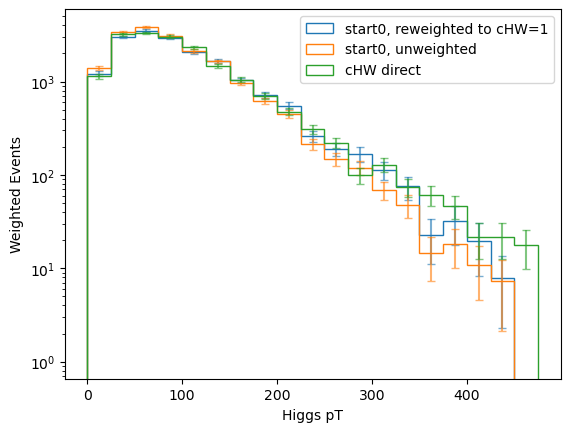

In [256]:
plot_reweighting("start0", events_dict, json_paths, operator="cHW")

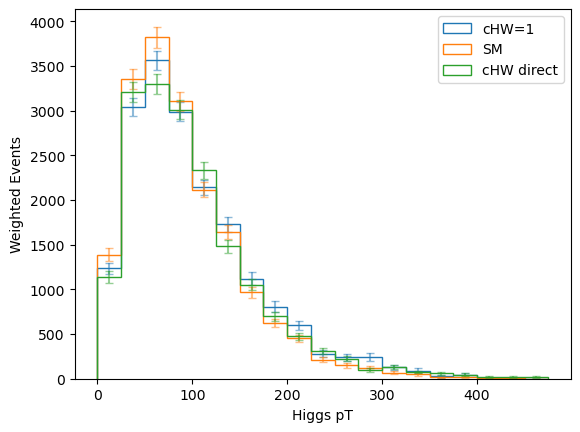

In [121]:
#start0
start0_higgses = start0_events.LHEPart[start0_events.LHEPart.pdgId == 25]
start0_h_pt = start0_higgses.pt
start0_h_pt = ak.firsts(start0_h_pt)

start0_json_path = '/uscms/home/azhou/nobackup/smeft/analysis/start0_5000_quad_fit_coeffs_per_bin.json'

#cHW for comparison
cHW_higgses = cHW_events.LHEPart[cHW_events.LHEPart.pdgId == 25]
cHW_h_pt = ak.firsts(cHW_higgses.pt)

#target points for reweighting
only_cHW = {'cHW': 1.0}
only_cHWtil = {'cHWtil': 1.0}
start0_og_wc_point = {}

#Weight calculations
weights_start0 = ak.to_numpy(start0_events.genWeight)

weights_cHW = weights_start0* reweight(higgs_pt = start0_h_pt,
         fit_coefficients_json_path = start0_json_path, 
         wc_target = only_cHW, 
         og_wc_point = start0_og_wc_point)

weights_cHWtil = weights_start0* reweight(higgs_pt = start0_h_pt,
         fit_coefficients_json_path = start0_json_path, 
         wc_target = only_cHWtil, 
         og_wc_point = start0_og_wc_point)

#error bars determination
cHW_reweighted_hist, bin_edges = np.histogram(start0_h_pt, bins=bins, weights=weights_cHW)
cHW_reweighted_hist_squared, _ = np.histogram(start0_h_pt, bins=bins, weights=weights_cHW**2)
cHW_reweighted_error = np.sqrt(cHW_reweighted_hist_squared)

start0_reweighted_hist, bin_edges = np.histogram(start0_h_pt, bins=bins, weights=weights_start0)
start0_reweighted_hist_squared, bin_edges = np.histogram(start0_h_pt, bins=bins, weights=weights_start0**2)
start0_reweighted_error = np.sqrt(start0_reweighted_hist_squared)

cHW_direct_hist, bin_edges = np.histogram(cHW_h_pt, bins=bins, weights=ak.to_numpy(cHW_events.genWeight))
cHW_direct_hist_squared, bin_edges = np.histogram(cHW_h_pt, bins=bins, weights=(ak.to_numpy(cHW_events.genWeight))**2)
cHW_direct_error = np.sqrt(cHW_direct_hist_squared)

bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
bins = np.arange(0, 500, 25)

#plots
plt.hist(start0_h_pt, bins= bins, weights=weights_cHW, histtype='step', label='cHW=1')
plt.errorbar(bin_centers, cHW_reweighted_hist, yerr=cHW_reweighted_error, capsize=3,
             linestyle='none',alpha = 0.5, color= 'tab:blue')

plt.hist(start0_h_pt, bins= bins, weights=weights_start0, histtype='step', label='SM')
plt.errorbar(bin_centers, start0_reweighted_hist, yerr=start0_reweighted_error, capsize=3,
             linestyle='none',alpha = 0.5, color= 'tab:orange')

plt.hist(cHW_h_pt, bins= bins, weights=ak.to_numpy(cHW_events.genWeight), histtype ='step', label='cHW direct')
plt.errorbar(bin_centers, cHW_direct_hist, yerr=cHW_direct_error, capsize=3,
             linestyle='none',alpha = 0.5, color= 'tab:green')

plt.xlabel("Higgs pT")
plt.ylabel("Weighted Events")
plt.legend()
plt.show()

Average chw ratio (should be ~0.98): 1.007452789359716
Average chwtil ratio (should be ~1.04): 1.0633911842862125


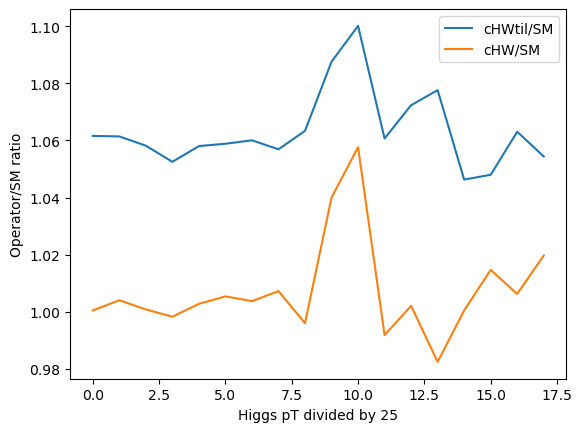

In [251]:
#Checking ratio of histograms: cHWtil vs. SM
bins = np.arange(0, 500, 25)

def to_numpy_flat(x):
    if isinstance(x, ak.Array):
        return ak.to_numpy(ak.flatten(x))
    elif isinstance(x, np.ndarray):
        return x.reshape(-1)
    else:
        return np.array(x).reshape(-1)

h_pt_flat = ak.to_numpy(start0_h_pt)
w_sm_flat = ak.to_numpy(weights_start0)

sm_hist_vals, _ = np.histogram(ak.to_numpy(start0_h_pt), bins=bins, weights=ak.to_numpy(weights_start0))
chw_hist_vals, _ = np.histogram(ak.to_numpy(start0_h_pt), bins=bins, weights=ak.to_numpy(weights_cHW))
chwtil_hist_vals, _ = np.histogram(ak.to_numpy(start0_h_pt), bins=bins, weights=ak.to_numpy(weights_cHWtil))

sm_hist = np.array(np.asarray(sm_hist_vals, dtype=float))
chw_hist = np.array(np.asarray(chw_hist_vals,dtype=float))
chwtil_hist = np.array(np.asarray(chwtil_hist_vals, dtype=float))

ratio_chw = np.where(sm_hist != 0, chw_hist /sm_hist, 0.0)
ratio_chwtil  = np.where(sm_hist != 0, chwtil_hist/sm_hist, 0.0)

ratio_chw = np.trim_zeros(ratio_chw, trim='b')
ratio_chwtil = np.trim_zeros(ratio_chwtil, trim='b')


#plt.plot(ratio_chw, label='cHW/SM')
plt.plot(ratio_chwtil, label='cHWtil/SM')
plt.plot(ratio_chw, label='cHW/SM')
print('Average chw ratio (should be ~0.98):', np.mean(ratio_chw))
print('Average chwtil ratio (should be ~1.04):', np.mean(ratio_chwtil))

plt.legend()
# plt.grid(True, alpha=0.3)
plt.ylabel("Operator/SM ratio")
plt.xlabel("Higgs pT divided by 25")
plt.show()

[6 7 6 ... 4 9 0]
[6 7 6 ... 4 9 0]


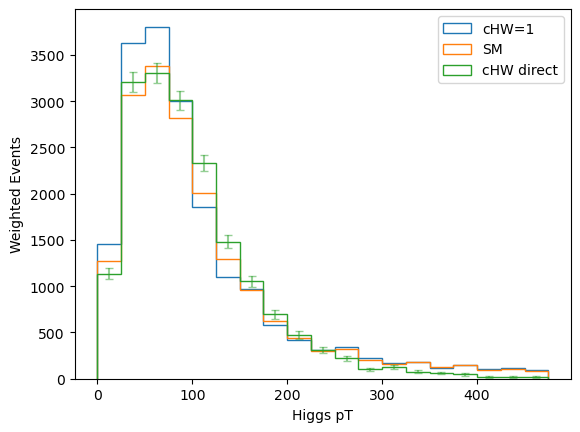

In [264]:
start1_higgses = start1_events.LHEPart[start1_events.LHEPart.pdgId == 25]
start1_h_pt = start1_higgses.pt
start1_h_pt = ak.firsts(start1_h_pt)

start1_json_path = '/uscms/home/azhou/nobackup/smeft/analysis/start1_5000_quad_fit_coeffs_per_bin.json'

only_cHW = {'cHW': 1.0}
only_cHWtil = {'cHWtil': 1.0}
start1_og_wc_point = og_wc_point_start1

weights_start1 = ak.to_numpy(start1_events.genWeight)

weights_cHW = weights_start1 * reweight(higgs_pt = start1_h_pt,
         fit_coefficients_json_path = start1_json_path, 
         wc_target = only_cHW, 
         og_wc_point = start1_og_wc_point)

weights_cHWtil = weights_start1 * reweight(higgs_pt = start1_h_pt,
         fit_coefficients_json_path = start1_json_path, 
         wc_target = only_cHWtil, 
         og_wc_point = start1_og_wc_point)

bins = np.arange(0, 500, 25)
plt.hist(start1_h_pt, bins=bins, weights=weights_cHW, histtype='step', label='cHW=1')
#plt.hist(start1_h_pt, bins=bins, weights=weights_cHWtil, histtype='step', label='cHWtil=1')
plt.hist(start1_h_pt, bins=bins, weights=weights_start1, histtype='step', label='SM') # this should still have weights: genweights

plt.hist(cHW_h_pt, bins= bins, weights=ak.to_numpy(cHW_events.genWeight), histtype ='step', label='cHW direct')
plt.errorbar(bin_centers, cHW_direct_hist, yerr=cHW_direct_error, capsize=3,
             linestyle='none',alpha = 0.5, color= 'tab:green')

plt.xlabel("Higgs pT")
plt.ylabel("Weighted Events")
plt.legend()
plt.show()

[0.87041902 0.87041901 0.87041636 0.87042169 0.87041467 0.98823046
 0.98825133 0.9882627  0.9882627  0.98823994 0.99657552 0.99657552
 0.99657552 0.99657552 0.99657552 0.98538243 0.98538243 0.98538243
 0.98538243 0.98538243 0.97324143 0.97324143 0.97324143 0.97324143
 0.97324143 0.97779864 0.97779864 0.97779864 0.97779864 0.97779864
 0.97303326 0.97303326 0.97303326 0.97303326 0.97303326 0.94896271
 0.94896271 0.94896271 0.94896271 0.94896271 1.01057592 1.01057592
 1.01057592 1.01057592 1.01057592 0.94995344 0.94995344 0.94995344
 0.94995344 0.94995344 0.9953508  0.9953508  0.9953508  0.99536703
 0.9953508  0.99141712 0.99141712 0.99141712 0.99141712 0.99141712
 0.95020492 0.95020492 0.95020492 0.95020492 0.95020492 0.98925739
 0.98925739 0.98925739 0.98925739 0.98925739 0.97207988 0.97207988
 0.97207988 0.97207988 0.97207988 0.95923958 0.95923958 0.95923958
 0.95923958 0.95923958 0.98380041 0.98380041 0.98380041 0.98380041
 0.98380041 0.97185321 0.97185321 0.97185321 0.97185321 0.9718

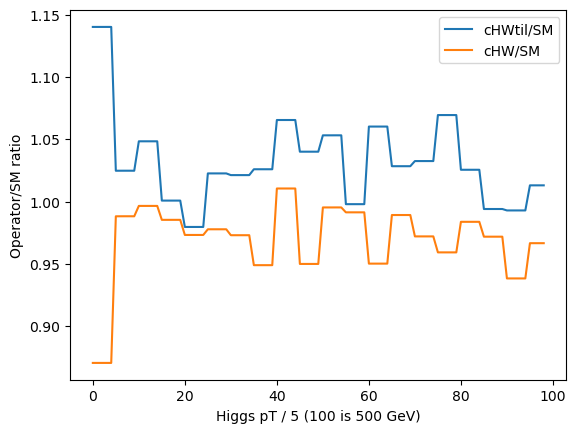

In [203]:
#Checking ratio of histograms: cHWtil vs. SM
bins = np.arange(0, 500, 25)

h_pt_flat = ak.to_numpy(start1_h_pt)
w_sm_flat = ak.to_numpy(weights_start1)

sm_hist_vals, _ = np.histogram(ak.to_numpy(start1_h_pt), bins=bins, weights=ak.to_numpy(weights_start1))
chw_hist_vals, _ = np.histogram(ak.to_numpy(start1_h_pt), bins=bins, weights=ak.to_numpy(weights_cHW))
chwtil_hist_vals, _ = np.histogram(ak.to_numpy(start1_h_pt), bins=bins, weights=ak.to_numpy(weights_cHWtil))

sm_hist = np.array(np.asarray(sm_hist_vals, dtype=float))
chw_hist = np.array(np.asarray(chw_hist_vals,dtype=float))
chwtil_hist = np.array(np.asarray(chwtil_hist_vals, dtype=float))

ratio_chw = np.where(sm_hist != 0, chw_hist /sm_hist, 0.0)
ratio_chwtil  = np.where(sm_hist != 0, chwtil_hist/sm_hist, 0.0)

plt.plot(ratio_chwtil, label='cHWtil/SM')
plt.plot(ratio_chw, label='cHW/SM')
print(ratio_chw)

plt.legend()
# plt.grid(True, alpha=0.3)
plt.ylabel("Operator/SM ratio")
plt.xlabel("Higgs pT / 5 (100 is 500 GeV)")
plt.show()